In [28]:
import json
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

In [29]:
def load_all_data_from_json(file_path):
    with open(file_path, "r") as file:
        data = json.load(file)
    return data

In [30]:
def load_values_from_json(file_path):
    with open(file_path, "r") as file:
        data_org = json.load(file)
    return list(data_org.values())

In [31]:
def get_files_with_cd(file_path, data_values, th):
    all_data = load_all_data_from_json(file_path)
    threshold = th
    keys_above_threshold = [key for key, value in all_data.items() if value > threshold]
    
    print(f"\nObjects whith Chamfer > {threshold}:")
    for key in keys_above_threshold:
        print(key)

    # Total number of files
    print(f"\nNumber of objects with Chamfer > {threshold}: {len(keys_above_threshold)} of {len(data_values)}")

In [32]:
def generate_histogram(data, bins, alpha, title, class_labels, means, colors):
    bins = 50
    plt.figure(figsize=(8, 4))

    all_data = np.concatenate(data)
    bin_edges = np.histogram_bin_edges(all_data, bins=bins)

    for i in range(len(data)):
        plt.hist(data[i], bins=bin_edges, alpha=alpha, color=colors[i], label=class_labels[i])
    for i in range(len(data)):    
        plt.axvline(means[i], color=colors[i], linestyle='--', linewidth=1.5, label=f"{class_labels[i]} Mean: {round(means[i], 3)}")

    # Add legend and labels
    plt.legend()
    plt.xlabel('Chamfer Distance Results')
    plt.ylabel('Frequency')
    plt.title(title)
    plt.show()

In [ ]:
mpl.rcParams.update({
    'svg.fonttype': 'none',        # texto editable en SVG
    'pdf.fonttype': 42,            # texto como texto, no curvas
    'font.family': 'STIXGeneral',  # "Times-like" portátil
    'mathtext.fontset': 'stix'
})

In [68]:
def generate_histogram_and_save(data, bins, alpha, title, class_labels, means, colors, output_path):
    
    bins = 50
    plt.figure(figsize=(6, 4))

    all_data = np.concatenate(data)
    bin_edges = np.histogram_bin_edges(all_data, bins=bins)

    for i in range(len(data)):
        plt.hist(data[i], bins=bin_edges, alpha=alpha, color=colors[i], label=class_labels[i])
    for i in range(len(data)):    
        plt.axvline(means[i], color=colors[i], linestyle='--', linewidth=1.5, label=f"{class_labels[i]} Mean: {round(means[i], 3)}")

    # Add legend and labels
    plt.legend()
    plt.xlabel('Chamfer Distance Results')
    plt.ylabel('Frequency')
    plt.title(title)
    plt.tight_layout()

    pdf_path = output_path.replace('.svg', '.pdf')
    plt.savefig(pdf_path, format='pdf', transparent=False)
    plt.show()
    plt.close()
    print(f"✅ Histograma guardado en: {output_path}")

# ShapeNet 1000 Objects

## Centroid x = 0

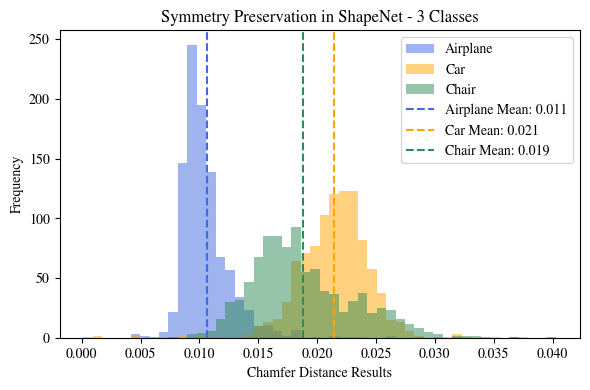

✅ Histograma guardado en: mean_shapeNet.pdf


In [69]:
file_path_airplane = "Symmetry_Computation/Results_CD/centered_shapenet1000_cd_results_airplane.json"
shapenet1000_airplane_data = load_values_from_json(file_path_airplane)  # Limiting to 405 samples
airplane_mean = np.mean(shapenet1000_airplane_data)

file_path_car = "Symmetry_Computation/Results_CD/centered_shapenet1000_cd_results_car.json"
shapenet1000_car_data = load_values_from_json(file_path_car)  # Limiting to 405 samples
car_mean = np.mean(shapenet1000_car_data)

file_path_chair = "Symmetry_Computation/Results_CD/centered_shapenet1000_cd_results_chair.json"
shapenet1000_chair_data = load_values_from_json(file_path_chair)  # Limiting to 405 samples
chair_mean = np.mean(shapenet1000_chair_data)

data = [shapenet1000_airplane_data, shapenet1000_car_data, shapenet1000_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [airplane_mean, car_mean, chair_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Preservation in ShapeNet - 3 Classes", class_labels=class_labels, means=means, colors=colors)
generate_histogram_and_save(data=data, bins=30, alpha=0.5, title="Symmetry Preservation in ShapeNet - 3 Classes", class_labels=class_labels, means=means, colors=colors, output_path="mean_shapeNet.pdf")

# Objects with CD greater than 0.03
#get_files_with_cd(file_path, data, 0.03)

## Original Objects

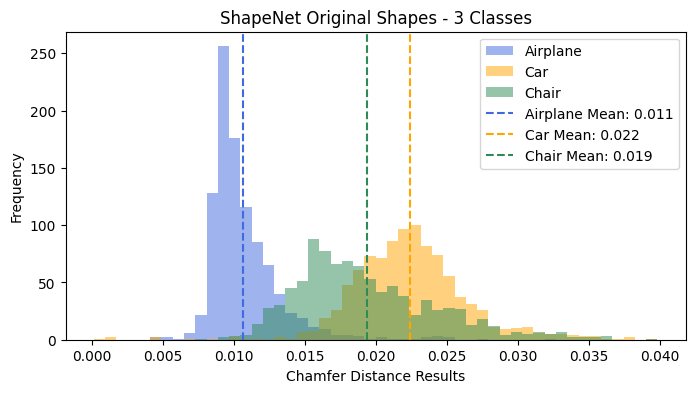

In [35]:
file_path_airplane = "Symmetry_Computation/Results_CD/shapenet1000_cd_results_airplane.json"
shapenet1000_airplane_data = load_values_from_json(file_path_airplane)
airplane_mean = np.mean(shapenet1000_airplane_data)

file_path_car = "Symmetry_Computation/Results_CD/shapenet1000_cd_results_car.json"
shapenet1000_car_data = load_values_from_json(file_path_car)
car_mean = np.mean(shapenet1000_car_data)

file_path_chair = "Symmetry_Computation/Results_CD/shapenet1000_cd_results_chair.json"
shapenet1000_chair_data = load_values_from_json(file_path_chair)
chair_mean = np.mean(shapenet1000_chair_data)

data = [shapenet1000_airplane_data, shapenet1000_car_data, shapenet1000_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [airplane_mean, car_mean, chair_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="ShapeNet Original Shapes - 3 Classes", class_labels=class_labels, means=means, colors=colors)

# Objects with CD greater than 0.03
#get_files_with_cd(file_path, data, 0.03)

# PVD 1000 objects

## Original CKPT

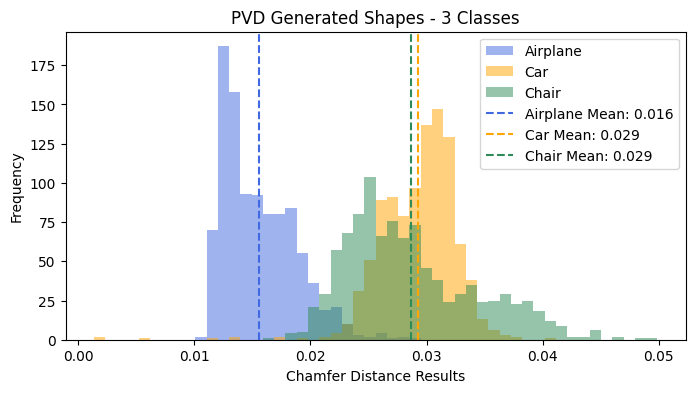

In [36]:
file_path = "Symmetry_Computation/Results_CD/centered_pvd1000_cd_results_airplane.json"
pvd1000_airplane_data = load_values_from_json(file_path)  # Limiting to 405 samples
pvd_original_airplane_mean = np.mean(pvd1000_airplane_data)

file_path = "Symmetry_Computation/Results_CD/centered_pvd1000_cd_results_car.json"
pvd1000_car_data = load_values_from_json(file_path)  # Limiting to 352 samples
pvd_original_car_mean = np.mean(pvd1000_car_data)

file_path = "Symmetry_Computation/Results_CD/centered_pvd1000_cd_results_chair.json"
pvd1000_chair_data = load_values_from_json(file_path)  # Limiting to 651 samples
pvd_original_chair_mean = np.mean(pvd1000_chair_data)

data = [pvd1000_airplane_data, pvd1000_car_data, pvd1000_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [pvd_original_airplane_mean, pvd_original_car_mean, pvd_original_chair_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Generated Shapes - 3 Classes", class_labels=class_labels, means=means, colors=colors)

## Over Half Objects - Airplane

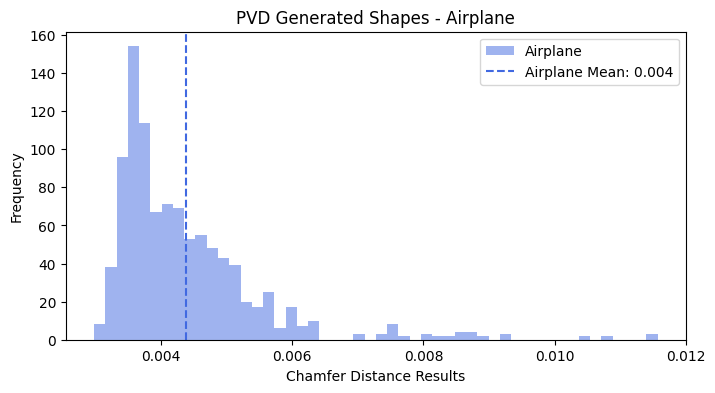

In [37]:
file_path = "Symmetry_Computation/Results_CD_Over_Half/cd_res_PVD_airplane.json"
pvd405_airplane_data = load_values_from_json(file_path)
pvd405_airplane_mean = np.mean(pvd405_airplane_data)

data = [pvd405_airplane_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["Airplane"] # , "Car", "Chair"
means = [pvd405_airplane_mean] # , pvd_car_mean, pvd_chair_mean
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Generated Shapes - Airplane", class_labels=class_labels, means=means, colors=colors)

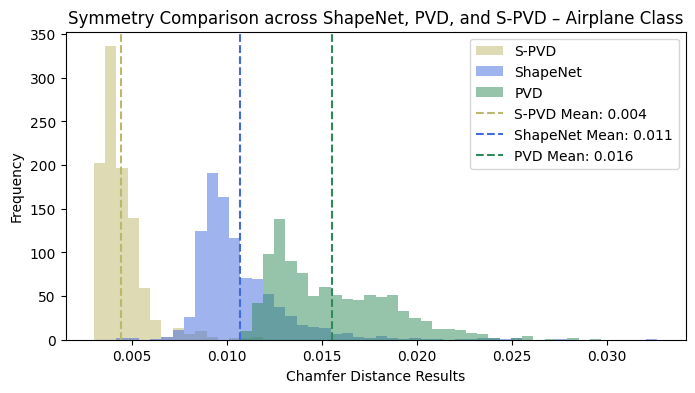

In [38]:
data = [pvd405_airplane_data, shapenet1000_airplane_data, pvd1000_airplane_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["S-PVD", "ShapeNet", "PVD"] # , "Car", "Chair"
means = [pvd405_airplane_mean, airplane_mean, pvd_original_airplane_mean] # , pvd_car_mean, pvd_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, PVD, and S-PVD – Airplane Class", class_labels=class_labels, means=means, colors=colors)

## Over Half Objects - Car

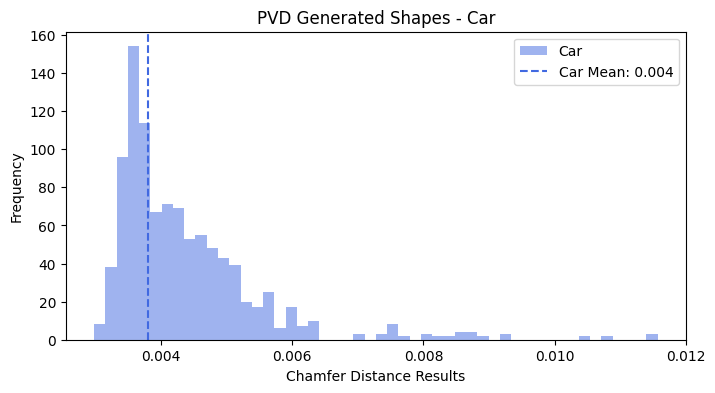

In [39]:
file_path = "Symmetry_Computation/Results_CD_Over_Half/cd_res_PVD_car.json"
pvd352_car_data = load_values_from_json(file_path)
pvd352_car_mean = np.mean(pvd352_car_data)

data = [pvd405_airplane_data]
class_labels = ["Car"]
means = [pvd352_car_mean]
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Generated Shapes - Car", class_labels=class_labels, means=means, colors=colors)

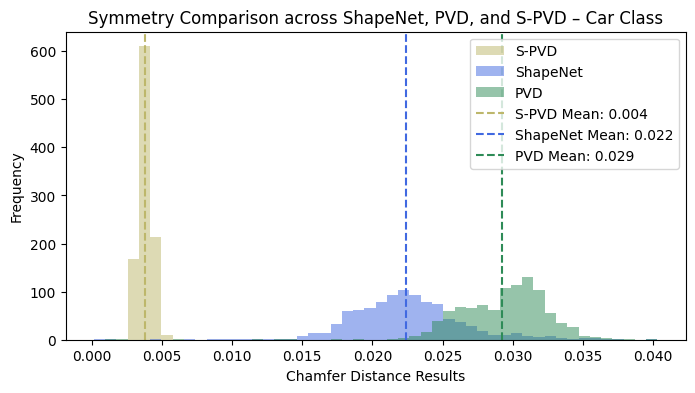

In [40]:
data = [pvd352_car_data, shapenet1000_car_data, pvd1000_car_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["S-PVD", "ShapeNet", "PVD"] # , "Car", "Chair"
means = [pvd352_car_mean, car_mean, pvd_original_car_mean] # , pvd_car_mean, pvd_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, PVD, and S-PVD – Car Class", class_labels=class_labels, means=means, colors=colors)

## Over Half Objects - Chair

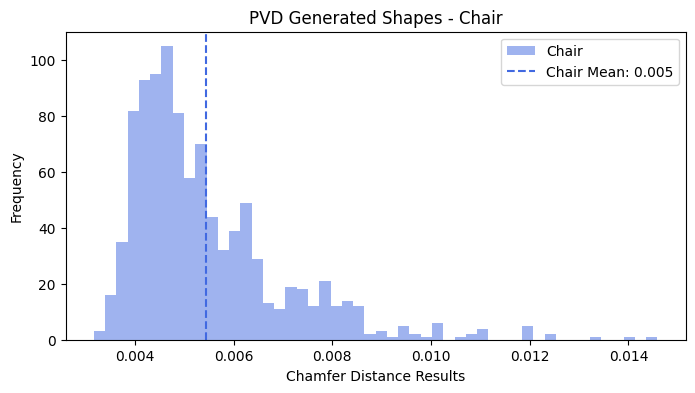

In [41]:
file_path = "Symmetry_Computation/Results_CD_Over_Half/cd_res_PVD_chair.json"
pvd651_chair_data = load_values_from_json(file_path)
pvd651_chair_mean = np.mean(pvd651_chair_data)

data = [pvd651_chair_data]
class_labels = ["Chair"]
means = [pvd651_chair_mean] 
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Generated Shapes - Chair", class_labels=class_labels, means=means, colors=colors)

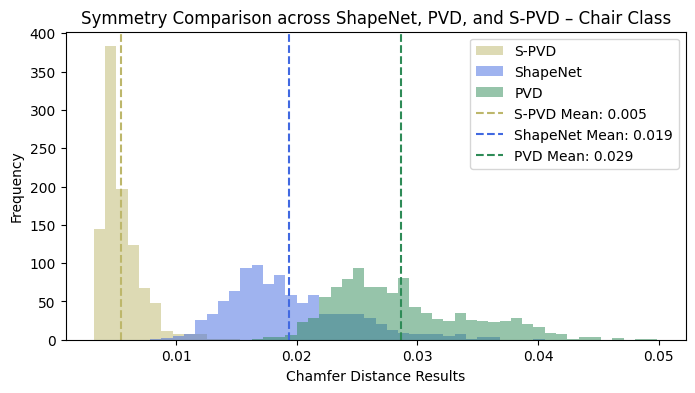

In [42]:
data = [pvd651_chair_data, shapenet1000_chair_data, pvd1000_chair_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["S-PVD", "ShapeNet", "PVD"] # , "Chair", "Chair"
means = [pvd651_chair_mean, chair_mean, pvd_original_chair_mean] # , pvd_Chair_mean, pvd_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, PVD, and S-PVD – Chair Class", class_labels=class_labels, means=means, colors=colors)

# LION 250 objects

## Centroid x = 0

1000
1000
1000


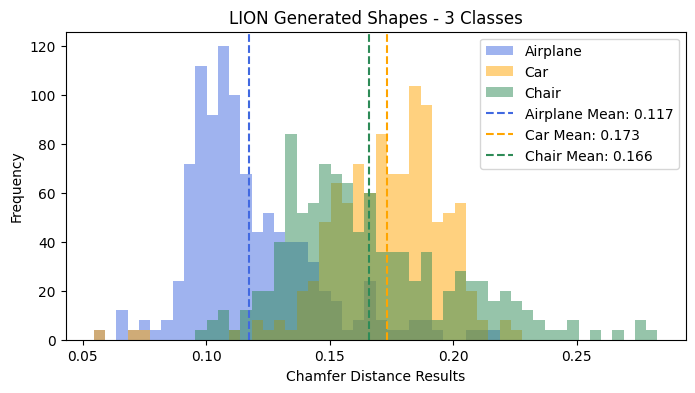

In [43]:
file_path = "Symmetry_Computation/Results_CD/centered_lion250_cd_results_airplane.json"
lion250_airplane_data = load_values_from_json(file_path)
lion_centroid_airplane_mean = np.mean(lion250_airplane_data)

file_path = "Symmetry_Computation/Results_CD/centered_lion250_cd_results_car.json"
lion250_car_data = load_values_from_json(file_path)
lion_centroid_car_mean = np.mean(lion250_car_data)

file_path = "Symmetry_Computation/Results_CD/centered_lion250_cd_results_chair.json"
lion250_chair_data = load_values_from_json(file_path)
lion_centroid_chair_mean = np.mean(lion250_chair_data)

print(len(lion250_airplane_data))
print(len(lion250_car_data))
print(len(lion250_chair_data))

data = [lion250_airplane_data, lion250_car_data, lion250_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [lion_centroid_airplane_mean, lion_centroid_car_mean, lion_centroid_chair_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="LION Generated Shapes - 3 Classes", class_labels=class_labels, means=means, colors=colors)

# XCube 1000 objects

## Centroid x = 0

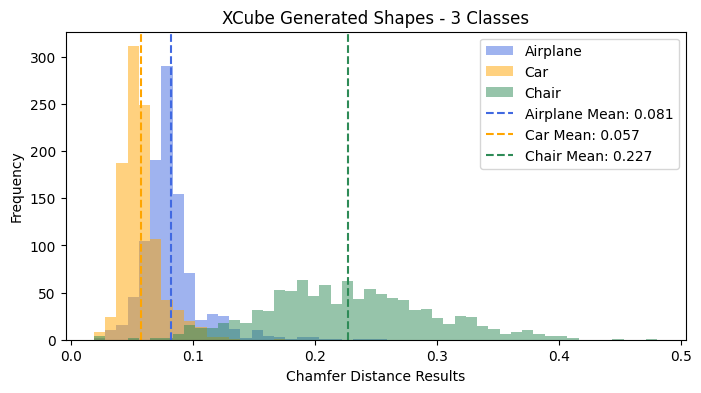

In [44]:
file_path = "Symmetry_Computation/Results_CD/centered_xcube1000_cd_results_airplane.json"
xcube1000_airplane_data = load_values_from_json(file_path)
xcube_centroid_airplane_mean = np.mean(xcube1000_airplane_data)

file_path = "Symmetry_Computation/Results_CD/centered_xcube1000_cd_results_car.json"
xcube1000_car_data = load_values_from_json(file_path)
xcube_centroid_car_mean = np.mean(xcube1000_car_data)

file_path = "Symmetry_Computation/Results_CD/centered_xcube1000_cd_results_chair.json"
xcube1000_chair_data = load_values_from_json(file_path)
xcube_centroid_chair_mean = np.mean(xcube1000_chair_data)

data = [xcube1000_airplane_data, xcube1000_car_data, xcube1000_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [xcube_centroid_airplane_mean, xcube_centroid_car_mean, xcube_centroid_chair_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="XCube Generated Shapes - 3 Classes", class_labels=class_labels, means=means, colors=colors)

# SLIDE 1000 objects

## Centroid x = 0

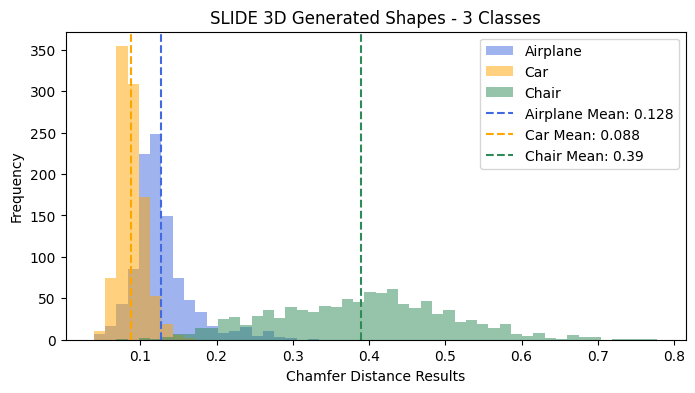

In [45]:
file_path = "Symmetry_Computation/Results_CD/centered_slide1000_cd_results_airplane.json"
slide1000_airplane_data = load_values_from_json(file_path)
slide_centroid_airplane_mean = np.mean(slide1000_airplane_data)

file_path = "Symmetry_Computation/Results_CD/centered_slide1000_cd_results_car.json"
slide1000_car_data = load_values_from_json(file_path)
slide_centroid_car_mean = np.mean(slide1000_car_data)

file_path = "Symmetry_Computation/Results_CD/centered_slide1000_cd_results_chair.json"
slide1000_chair_data = load_values_from_json(file_path)
slide_centroid_chair_mean = np.mean(slide1000_chair_data)

data = [slide1000_airplane_data, slide1000_car_data, slide1000_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [slide_centroid_airplane_mean, slide_centroid_car_mean, slide_centroid_chair_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="SLIDE 3D Generated Shapes - 3 Classes", class_labels=class_labels, means=means, colors=colors)

# TIGER 1000 objects

In [46]:
""" file_path = "Symmetry_Computation/Results_CD/tiger1000_cd_results_airplane.json"
tiger1000_airplane_data = load_values_from_json(file_path)
tiger_airplane_mean = np.mean(tiger1000_airplane_data)

file_path = "Symmetry_Computation/Results_CD/tiger1000_cd_results_car.json"
tiger1000_car_data = load_values_from_json(file_path)
tiger_car_mean = np.mean(tiger1000_car_data)

file_path = "Symmetry_Computation/Results_CD/tiger1000_cd_results_chair.json"
tiger1000_chair_data = load_values_from_json(file_path)
tiger_chair_mean = np.mean(tiger1000_chair_data)

data = [tiger1000_airplane_data, tiger1000_car_data, tiger1000_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [tiger_airplane_mean, tiger_car_mean, tiger_chair_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="TIGER Generated Shapes - 3 Classes", class_labels=class_labels, means=means, colors=colors) """

' file_path = "Symmetry_Computation/Results_CD/tiger1000_cd_results_airplane.json"\ntiger1000_airplane_data = load_values_from_json(file_path)\ntiger_airplane_mean = np.mean(tiger1000_airplane_data)\n\nfile_path = "Symmetry_Computation/Results_CD/tiger1000_cd_results_car.json"\ntiger1000_car_data = load_values_from_json(file_path)\ntiger_car_mean = np.mean(tiger1000_car_data)\n\nfile_path = "Symmetry_Computation/Results_CD/tiger1000_cd_results_chair.json"\ntiger1000_chair_data = load_values_from_json(file_path)\ntiger_chair_mean = np.mean(tiger1000_chair_data)\n\ndata = [tiger1000_airplane_data, tiger1000_car_data, tiger1000_chair_data]\nclass_labels = ["Airplane", "Car", "Chair"]\nmeans = [tiger_airplane_mean, tiger_car_mean, tiger_chair_mean]\ncolors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki\n\ngenerate_histogram(data=data, bins=30, alpha=0.5, title="TIGER Generated Shapes - 3 Classes

# Joint histograms

## Airplane

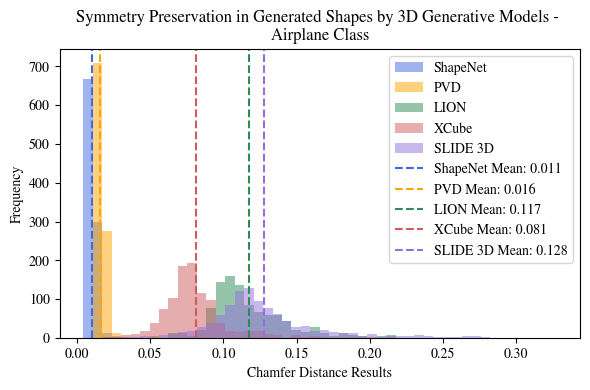

✅ Histograma guardado en: original_airplane.pdf


In [70]:
data = [shapenet1000_airplane_data, pvd1000_airplane_data, lion250_airplane_data, xcube1000_airplane_data, slide1000_airplane_data]
class_labels = ["ShapeNet", "PVD", "LION",  "XCube", "SLIDE 3D"]
means = [airplane_mean, pvd_original_airplane_mean, lion_centroid_airplane_mean, xcube_centroid_airplane_mean, slide_centroid_airplane_mean]
colors = ["royalblue", "orange", "seagreen", "indianred", "mediumpurple"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Preservation in Generated Shapes by 3D Generative Models - \nAirplane Class", class_labels=class_labels, means=means, colors=colors)
generate_histogram_and_save(data=data, bins=30, alpha=0.5, title="Symmetry Preservation in Generated Shapes by 3D Generative Models - \nAirplane Class", class_labels=class_labels, means=means, colors=colors, output_path="original_airplane.pdf")

## Car

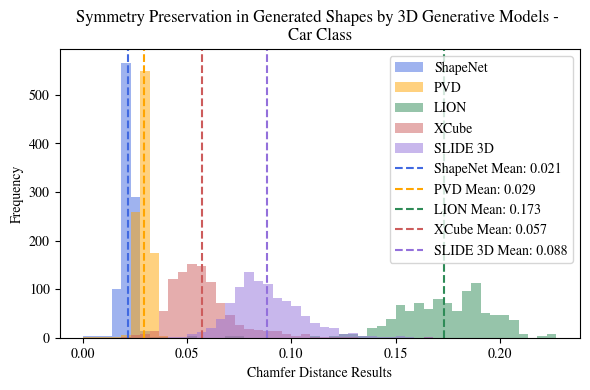

✅ Histograma guardado en: original_car.pdf


In [71]:
data = [shapenet1000_car_data, pvd1000_car_data, lion250_car_data, xcube1000_car_data, slide1000_car_data]
class_labels = ["ShapeNet", "PVD", "LION",  "XCube", "SLIDE 3D"]
means = [car_mean, pvd_original_car_mean, lion_centroid_car_mean, xcube_centroid_car_mean, slide_centroid_car_mean]
colors = ["royalblue", "orange", "seagreen", "indianred", "mediumpurple"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Preservation in Generated Shapes by 3D Generative Models - \nCar Class", class_labels=class_labels, means=means, colors=colors)
generate_histogram_and_save(data=data, bins=30, alpha=0.5, title="Symmetry Preservation in Generated Shapes by 3D Generative Models - \nCar Class", class_labels=class_labels, means=means, colors=colors, output_path="original_car.pdf")

## Chair

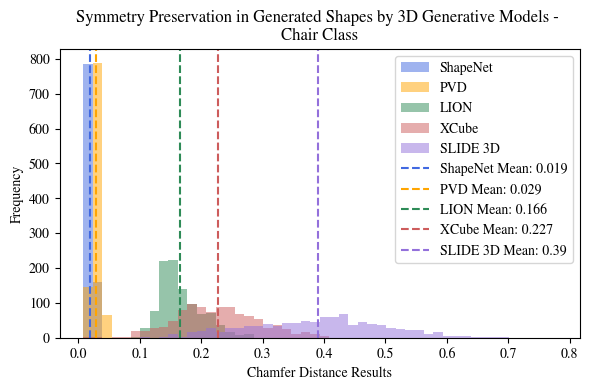

✅ Histograma guardado en: original_chair.pdf


In [72]:
data = [shapenet1000_chair_data, pvd1000_chair_data, lion250_chair_data, xcube1000_chair_data, slide1000_chair_data]
class_labels = ["ShapeNet", "PVD", "LION",  "XCube", "SLIDE 3D"]
means = [chair_mean, pvd_original_chair_mean, lion_centroid_chair_mean, xcube_centroid_chair_mean, slide_centroid_chair_mean]
colors = ["royalblue", "orange", "seagreen", "indianred", "mediumpurple"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Preservation in Generated Shapes by 3D Generative Models - \nChair Class", class_labels=class_labels, means=means, colors=colors)
generate_histogram_and_save(data=data, bins=30, alpha=0.5, title="Symmetry Preservation in Generated Shapes by 3D Generative Models - \nChair Class", class_labels=class_labels, means=means, colors=colors, output_path="original_chair.pdf")

Move all the objects with CD greater than 0.03 to a new directory

* Before class airplane:

Mean:  0.006508295065486582

Objects whith Chamfer > 0.03:
1286826ff37699a1a0d713eb26379316.npy,
4508864390ae424d663e50e76f163b3.npy,
7b6f528acc10d3fbcf5b9c6e0c7ce895.npy,
22829f20e331d563dd455eb19d4d269e.npy,
b51c1bb30371852fa325f626d0051e24.npy,
95bc1c56fd50037ce3f3aec01b086ba.npy,
1367266dc0a07c925d4533028830a79b.npy,
5d1594f792f3641583a1f09b027e5462.npy,
ccc0bbcc236bdff9c1ccec171a275967.npy,
43beab0c1cc46ae641b5a73cd6c05ccd.npy,
f5bb02c0df184488e0b6c670e0e97766.npy,
ea527508bb74f476f64801ad2940cdd5.npy,
f12b45a38f012a78ac4f72bf08dc79a6.npy,

Number of objects with Chamfer > 0.03: 13 of 1000

* Before class Car

Mean:  0.013061948376244829

Objects whith Chamfer > 0.03:
186646b16a670b7d69a949ac99a843c4.npy,
bb7ca919b59a3a2e6b418c7d9fedcaa9.npy,
82b9bbf2c5c630d9acc1f3191aab65d4.npy,
657ea4181e337213fa7c23b34a0b219.npy,
df7c767eba9455f651a95aaa6caba1d3.npy,
d1a54cb41a88702b1e8e2692714b2614.npy,
d1e2f84cc473956696e59b6a2c87ca55.npy,
4026bb045c2cfc669f4536d76626fb35.npy,
5b925881cf8678cabda733a39f84326d.npy,
8549c4948c7285f438acd89c0735f4f7.npy,
bfa01c632be2eb06e8a3b392b986583.npy,
5494ca610eb9fad59bd53ddfa65bb6b1.npy,

Number of objects with Chamfer > 0.03: 12 of 1000

* Before class Chair

Mean:  0.014481584478325931

Objects whith Chamfer > 0.03:
2dbe453ba389adf5f91663a74ccd2338.npy,
eff6231acedae01c17103f9c0716a636.npy,
a235f7c4947aab15bf40bda9de89848a.npy,
903a14845425ca3176e30bf48cd56fcd.npy,
40a32b11861df98133ec62ad9f83dbff.npy,
d15543efce9acacc8687ff9b0b4e4ac.npy,
e31c6c24a8d80ac35692a9640d6947fc.npy,
70ef2b4c4b287c4e3c00c853d8b7ab22.npy,
e71d05f223d527a5f91663a74ccd2338.npy,
6730fb4ca7c90ddccd8b2a7439d99cc3.npy,
215e557db4c4bb5d837b757304479228.npy,
709a5038988a70f58e6803fc947043b9.npy,
11e55ca087c74082feec1f13d2353f3.npy,
764abaffc5872775f0dff71ec76b46f7.npy,
fe57bad06e1f6dd9a9fe51c710ac111b.npy,
c5d880efc887f6f4f9111ef49c078dbe.npy,
cc811f0c28012f493c528a26a44a30b6.npy,
74e14880b5aab8e3490ad276cd2af3a4.npy,
fe20f6a58ca6c84c914eb005afa6475b.npy,
b1d9c55bd4e8ded1c76575d5e6d323f2.npy,
474b82a849e5064fa9dea4db53ba3dd.npy,
260f65e1b1baaf7c7b707c797539b200.npy,
28d27f1204c1b3de6512b7b24f3d84.npy,
fc5f813d499cfd84d540c52e6ddbbebc.npy,
94645127bd4168e03e63b721c3743983.npy,
b58b8a4646d14b7c202339ec5396045d.npy,
9a3a80065f75e33d822e11aea23332c0.npy,
6df97f6b123be35b71a782a4379556c7.npy,
53316b8bdd729c87a516ad65be981ae.npy,
6d199c744b17d85953735b417976bbf5.npy,
ce2acc9d7aea91a0988fec2229ccf13f.npy,
76ee694df725b5b4664b3b9b23ddfcbc.npy,
4f22f44c331ad407166390f4a0367453.npy,
50c446295496eca73542594e05cedc89.npy,
d5cadd520263753b65ae658fdfdd758d.npy,
6e5c0ca5ee70c88b77dbab4c80b965e5.npy,
670c7df7c840f78bcb7547c95fbdff26.npy,
e67d503940c1d95b73e5f839658fc536.npy,
4c9b6e0823be25ae52bee19dc0453f5e.npy,
61fb89fca404e37f598bcf8ac674b63d.npy,
f854fa8ee2fb6d715936c7265c890fef.npy,
451458fe90bd0f4144f23566597ec464.npy,
9e6564dce4cc128efc24661f5f8d5d00.npy,
cb5f7944ec02defcc6a2b7fc00a47507.npy,
18d391ede29e2edb990561fc34164364.npy,
329c2234d134dc89492d9da2668ec34c.npy,
42e1e9b71b87787fc8687ff9b0b4e4ac.npy,
55740c07554a726257f40ff86fe708ff.npy,
b83bebb013e4ddcabd1aeba6ff85928a.npy,
6b4622c4e15b5cc9f91663a74ccd2338.npy,
37e5a1f7f0409a3b81d7f282a3dff363.npy,
669a23c329080506d295b24579cf55b8.npy,

Number of objects with Chamfer > 0.03: 52 of 1000

In [50]:
import os
import shutil

# Lista de archivos con CD > 0.03
files_to_move = [
    "2dbe453ba389adf5f91663a74ccd2338.npy",
    "eff6231acedae01c17103f9c0716a636.npy",
    "a235f7c4947aab15bf40bda9de89848a.npy",
    "903a14845425ca3176e30bf48cd56fcd.npy",
    "40a32b11861df98133ec62ad9f83dbff.npy",
    "d15543efce9acacc8687ff9b0b4e4ac.npy",
    "e31c6c24a8d80ac35692a9640d6947fc.npy",
    "70ef2b4c4b287c4e3c00c853d8b7ab22.npy",
    "e71d05f223d527a5f91663a74ccd2338.npy",
    "6730fb4ca7c90ddccd8b2a7439d99cc3.npy",
    "215e557db4c4bb5d837b757304479228.npy",
    "709a5038988a70f58e6803fc947043b9.npy",
    "11e55ca087c74082feec1f13d2353f3.npy",
    "764abaffc5872775f0dff71ec76b46f7.npy",
    "fe57bad06e1f6dd9a9fe51c710ac111b.npy",
    "c5d880efc887f6f4f9111ef49c078dbe.npy",
    "cc811f0c28012f493c528a26a44a30b6.npy",
    "74e14880b5aab8e3490ad276cd2af3a4.npy",
    "fe20f6a58ca6c84c914eb005afa6475b.npy",
    "b1d9c55bd4e8ded1c76575d5e6d323f2.npy",
    "474b82a849e5064fa9dea4db53ba3dd.npy",
    "260f65e1b1baaf7c7b707c797539b200.npy",
    "28d27f1204c1b3de6512b7b24f3d84.npy",
    "fc5f813d499cfd84d540c52e6ddbbebc.npy",
    "94645127bd4168e03e63b721c3743983.npy",
    "b58b8a4646d14b7c202339ec5396045d.npy",
    "9a3a80065f75e33d822e11aea23332c0.npy",
    "6df97f6b123be35b71a782a4379556c7.npy",
    "53316b8bdd729c87a516ad65be981ae.npy",
    "6d199c744b17d85953735b417976bbf5.npy",
    "ce2acc9d7aea91a0988fec2229ccf13f.npy",
    "76ee694df725b5b4664b3b9b23ddfcbc.npy",
    "4f22f44c331ad407166390f4a0367453.npy",
    "50c446295496eca73542594e05cedc89.npy",
    "d5cadd520263753b65ae658fdfdd758d.npy",
    "6e5c0ca5ee70c88b77dbab4c80b965e5.npy",
    "670c7df7c840f78bcb7547c95fbdff26.npy",
    "e67d503940c1d95b73e5f839658fc536.npy",
    "4c9b6e0823be25ae52bee19dc0453f5e.npy",
    "61fb89fca404e37f598bcf8ac674b63d.npy",
    "f854fa8ee2fb6d715936c7265c890fef.npy",
    "451458fe90bd0f4144f23566597ec464.npy",
    "9e6564dce4cc128efc24661f5f8d5d00.npy",
    "cb5f7944ec02defcc6a2b7fc00a47507.npy",
    "18d391ede29e2edb990561fc34164364.npy",
    "329c2234d134dc89492d9da2668ec34c.npy",
    "42e1e9b71b87787fc8687ff9b0b4e4ac.npy",
    "55740c07554a726257f40ff86fe708ff.npy",
    "b83bebb013e4ddcabd1aeba6ff85928a.npy",
    "6b4622c4e15b5cc9f91663a74ccd2338.npy",
    "37e5a1f7f0409a3b81d7f282a3dff363.npy",
    "669a23c329080506d295b24579cf55b8.npy"
]

# Carpeta origen
source_dir = "/home/ncaytuir/Datasets/ShapeNetCore.v3.PC15k/03001627/train"

# Carpeta destino
dest_dir = "/home/ncaytuir/Datasets/ShapeNetCore.v3.PC15k/03001627/train_cd_0-03"

# Crear carpeta destino si no existe
os.makedirs(dest_dir, exist_ok=True)

# Mover los archivos
for filename in files_to_move:
    source_file = os.path.join(source_dir, filename)
    
    if os.path.exists(source_file):
        shutil.move(source_file, os.path.join(dest_dir, filename))
        print(f"Movido: {filename}")
    else:
        print(f"No encontrado: {filename}")

No encontrado: 2dbe453ba389adf5f91663a74ccd2338.npy
No encontrado: eff6231acedae01c17103f9c0716a636.npy
No encontrado: a235f7c4947aab15bf40bda9de89848a.npy
No encontrado: 903a14845425ca3176e30bf48cd56fcd.npy
No encontrado: 40a32b11861df98133ec62ad9f83dbff.npy
No encontrado: d15543efce9acacc8687ff9b0b4e4ac.npy
No encontrado: e31c6c24a8d80ac35692a9640d6947fc.npy
No encontrado: 70ef2b4c4b287c4e3c00c853d8b7ab22.npy
No encontrado: e71d05f223d527a5f91663a74ccd2338.npy
No encontrado: 6730fb4ca7c90ddccd8b2a7439d99cc3.npy
No encontrado: 215e557db4c4bb5d837b757304479228.npy
No encontrado: 709a5038988a70f58e6803fc947043b9.npy
No encontrado: 11e55ca087c74082feec1f13d2353f3.npy
No encontrado: 764abaffc5872775f0dff71ec76b46f7.npy
No encontrado: fe57bad06e1f6dd9a9fe51c710ac111b.npy
No encontrado: c5d880efc887f6f4f9111ef49c078dbe.npy
No encontrado: cc811f0c28012f493c528a26a44a30b6.npy
No encontrado: 74e14880b5aab8e3490ad276cd2af3a4.npy
No encontrado: fe20f6a58ca6c84c914eb005afa6475b.npy
No encontrado: